In [183]:
import numpy as np
import pandas as pd
import bisect

import os

import matplotlib.pyplot as plt
from matplotlib import colors, cm
import seaborn as sns
from matplotlib.colorbar import ColorbarBase


import statsmodels.api as sm

from pathlib import Path

from experiment.experiment import Experiment
from experiment.experiment_batcher import ExperimentBatcher

## Single experiment

In [185]:
exp = Experiment(Path("experiment/experiment_configs/experiment_BPI_2012_O_ct_aware.yaml"))
res = exp.run()

[Experiment]	    (1) Loaded log with 31244 events.
[Experiment]	    (2) Split log into 25032 train, 0 val, 6212 test cases.
[Experiment]	    (3) Identified 6 worktime intervals.
[Experiment]	    (4) Transformed log to worktime with column 'worktime:timestamp'.
[Experiment]	    (5) Generated prefixes: 106176 train, 0 val, 26942 test events.
[Experiment]	    (6) Engineered features: 10 features for 106176 train, 0 val, 26942 test events.
[Experiment]	    (7) Prepared target 'time_until_next_event': 106176 train, 0 val, 26942 test labels.
[Experiment]	    (8) Transformed data for model input into shape (21020, 30, 10) train, (0, 0, 10) val, (5209, 26, 10) test.
Epoch 1/100


E0000 00:00:1773520831.532090 1752305 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0382 - mae: 0.0382
Epoch 2/100
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0346 - mae: 0.0346
Epoch 3/100
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0336 - mae: 0.0336
Epoch 4/100
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0328 - mae: 0.0328
Epoch 5/100
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0326 - mae: 0.0326
Epoch 6/100
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0323 - mae: 0.0323
Epoch 7/100
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0319 - mae: 0.0319
Epoch 8/100
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0317 - mae: 0.0317
Epoch 9/100
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0316 - mae: 0.0316
Epoch 10/100
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0315 - mae: 0.0315
Epoch 11/100
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0313 - mae: 0.0313
Epoch 12/100
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0312 - mae: 0.0312
Epoch 13/100
657/657 ━━━━

E0000 00:00:1773521127.673938 1752305 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[Experiment]	    (10) Evaluated model.
[Experiment]	    (11) Saved experiment results to: artifacts/experiments/BPI_2012_O/BPI_2012_O_minmax_tax_20260314T204528Z.json
[Experiment]	    Experiment completed in 314.94 seconds.


In [187]:
df = res.pref_te

df = df.sort_values(by=["time:timestamp"])
df = df.groupby('case:concept:name').last()

df["y_pred"] = res.y_pred.values
df["y_true"] = res.y_true.values
df["abs_error"] = np.abs(df["y_pred"] - df["y_true"])

df["y_pred_absolute"] = df["time:timestamp"] + pd.to_timedelta(df["y_pred"], unit='s')
df["y_true_absolute"] = df["time:timestamp"] + pd.to_timedelta(df["y_true"], unit='s')

#df[["time:timestamp", "y_true_absolute", "y_pred", "y_true"]].head(10)
df.head(10)

,org:resource,lifecycle:transition,concept:name,time:timestamp,@@index,@@case_index,case:REG_DATE,case:AMOUNT_REQ,worktime:timestamp,prefix_length,y_pred,y_true,abs_error,y_pred_absolute,y_true_absolute
case:concept:name,,,,,,,,,,,,,,,
189805::prefix_0002,10931,COMPLETE,O_CREATED,2011-11-29 12:51:30+00:00,11857,1936,2011-11-29 12:31:07.629000+00:00,25000,6106 days 00:51:30,2,1.417066e+03,0.000000e+00,1.417066e+03,2011-11-29 13:15:07.065673828+00:00,2011-11-29 12:51:30+00:00
189805::prefix_0003,10931,COMPLETE,O_CREATED,2011-11-29 12:51:30+00:00,11857,1936,2011-11-29 12:31:07.629000+00:00,25000,6106 days 00:51:30,3,6.832943e+05,2.445569e+06,1.762275e+06,2011-12-07 10:39:44.312500+00:00,2011-12-27 20:10:59+00:00
189805::prefix_0004,10861,COMPLETE,O_CANCELLED,2011-12-27 20:10:59+00:00,11859,1936,2011-11-29 12:31:07.629000+00:00,25000,6117 days 12:10:59,4,7.653615e+02,0.000000e+00,7.653615e+02,2011-12-27 20:23:44.361511230+00:00,2011-12-27 20:10:59+00:00
189805::prefix_0005,10861,COMPLETE,O_CREATED,2011-12-27 20:10:59+00:00,11861,1936,2011-11-29 12:31:07.629000+00:00,25000,6117 days 12:10:59,5,1.722755e+03,0.000000e+00,1.722755e+03,2011-12-27 20:39:41.755493164+00:00,2011-12-27 20:10:59+00:00
189805::prefix_0006,10861,COMPLETE,O_SELECTED,2011-12-27 20:10:59+00:00,11860,1936,2011-11-29 12:31:07.629000+00:00,25000,6117 days 12:10:59,6,1.770940e+03,0.000000e+00,1.770940e+03,2011-12-27 20:40:29.940063477+00:00,2011-12-27 20:10:59+00:00
189805::prefix_0007,10861,COMPLETE,O_SELECTED,2011-12-27 20:10:59+00:00,11860,1936,2011-11-29 12:31:07.629000+00:00,25000,6117 days 12:10:59,7,1.185047e+06,2.585360e+06,1.400313e+06,2012-01-10 13:21:45.750000+00:00,2012-01-26 18:20:19+00:00
189805::prefix_0008,11180,COMPLETE,O_CANCELLED,2012-01-26 18:20:19+00:00,11864,1936,2011-11-29 12:31:07.629000+00:00,25000,6129 days 14:20:19,8,-5.661745e+02,0.000000e+00,5.661745e+02,2012-01-26 18:10:52.825500488+00:00,2012-01-26 18:20:19+00:00
189805::prefix_0009,11180,COMPLETE,O_CANCELLED,2012-01-26 18:20:19+00:00,11864,1936,2011-11-29 12:31:07.629000+00:00,25000,6129 days 14:20:19,9,2.011438e+03,2.000000e+00,2.009438e+03,2012-01-26 18:53:50.438232422+00:00,2012-01-26 18:20:21+00:00
189805::prefix_0010,11180,COMPLETE,O_CREATED,2012-01-26 18:20:21+00:00,11865,1936,2011-11-29 12:31:07.629000+00:00,25000,6129 days 14:20:21,10,1.274082e+03,0.000000e+00,1.274082e+03,2012-01-26 18:41:35.081787109+00:00,2012-01-26 18:20:21+00:00


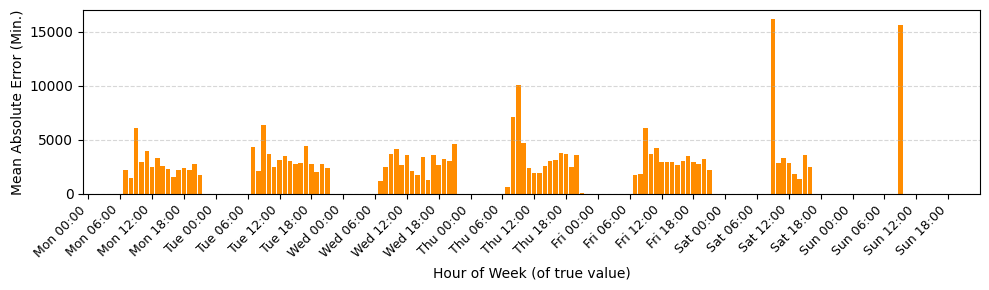

In [ ]:
def plot_mae_by_hour_of_week(df: pd.DataFrame, by="time:timestamp", use_heat_map=True, title = "Prediction Error by Hour of Week", xlabel="Hour of Week"):
    """
    Plots the Mean Absolute Error (MAE) in MINUTES aggregated by the hour of the week.
    Provides an option to color-code bars based on event volume.
    """
    # ---------------------------------------------------------
    # 1. Data Preparation
    # ---------------------------------------------------------
    plot_df = df.copy()
    plot_df['time:timestamp'] = pd.to_datetime(plot_df['time:timestamp'], utc=True)
    plot_df['y_true_absolute'] = pd.to_datetime(plot_df['y_true_absolute'], utc=True)
    
    # Calculate continuous hour of week [0, 167]
    plot_df['bucket_idx'] = (plot_df[by].dt.dayofweek * 24) + plot_df[by].dt.hour
    
    # Calculate Absolute Error in Minutes
    try:
        plot_df['abs_error_min'] = (plot_df['y_true'].dt.total_seconds() - plot_df['y_pred'].dt.total_seconds()).abs() / 60.0
    except Exception as e:
        plot_df['abs_error_min'] = (plot_df['y_true'] - plot_df['y_pred']).abs() / 60.0

    # Aggregate MAE and Event Count per hour
    agg_metrics = plot_df.groupby('bucket_idx').agg(
        mae_min=('abs_error_min', 'mean'),
        event_count=('abs_error_min', 'count')
    ).reindex(range(168))

    # ---------------------------------------------------------
    # 2. Visualization Setup
    # ---------------------------------------------------------
    fig, ax = plt.subplots(figsize=(10, 3))
    
    counts = agg_metrics['event_count'].fillna(0)
    
    # Configure bar colors depending on the selected visualization mode
    if use_heat_map:
        norm = colors.Normalize(vmin=counts.min(), vmax=counts.max())
        cmap = cm.get_cmap('plasma') 
        bar_colors = cmap(norm(counts.values))
    else:
        bar_colors = 'darkorange'

    # ---------------------------------------------------------
    # 3. Bar Plotting
    # ---------------------------------------------------------
    bars = ax.bar(
        agg_metrics.index,
        agg_metrics['mae_min'],
        color=bar_colors,
        width=0.85,
        align='center'
    )

    # ---------------------------------------------------------
    # 4. Formatting
    # ---------------------------------------------------------
    tick_indices = np.arange(0, 168, 6)
    day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
    
    def format_tick_label(idx):
        day_idx = idx // 24
        hour = idx % 24
        return f"{day_labels[day_idx]} {hour:02d}:00"

    tick_labels = [format_tick_label(i) for i in tick_indices]
    
    ax.set_xticks(tick_indices)
    ax.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=9)
    ax.set_xlim(-1, 168)
    
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Mean Absolute Error (Min.)")
    ax.set_title(title)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    
    # Render colorbar exclusively for heat map visualization
    if use_heat_map:
        sm = cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax, pad=0.01)
        cbar.set_label('Number of Events (Volume)', rotation=270, labelpad=15)
    
    plt.tight_layout()
    plt.show()
    
plot_mae_by_hour_of_week(df, by="y_true_absolute", use_heat_map=False, xlabel="Hour of Week (of true value)", title="")

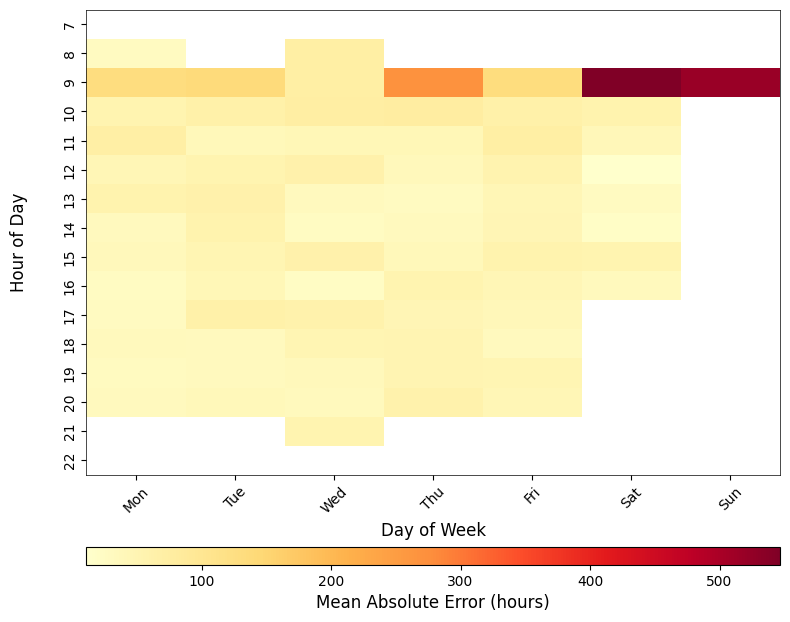

In [ ]:
def get_2d_error_matrix(df, min_entries=10):
    """Calculates MAE grouped by Day and Hour, masking low-frequency bins."""
    df_temp = df.copy()
    df_temp['y_true_absolute'] = pd.to_datetime(df_temp['y_true_absolute'], utc=True, errors='coerce')
    df_temp = df_temp.dropna(subset=['y_true_absolute'])
    
    if df_temp.empty:
        return pd.DataFrame(np.nan, index=range(7,23), columns=range(7))

    df_temp['day_of_week'] = df_temp['y_true_absolute'].dt.dayofweek
    df_temp['hour_of_day'] = df_temp['y_true_absolute'].dt.hour
    df_temp['abs_error_h'] = df_temp['abs_error'] / 3600

    pivot_mean = df_temp.pivot_table(index='hour_of_day', columns='day_of_week', 
                                    values='abs_error_h', aggfunc='mean')
    pivot_count = df_temp.pivot_table(index='hour_of_day', columns='day_of_week', 
                                     values='abs_error_h', aggfunc='count')
    
    pivot_mean[pivot_count < min_entries] = np.nan
    return pivot_mean.reindex(index=range(7,23), columns=range(7))

# --- 2. Setup Plot Data ---
# Assuming 'target_df' is your specific DataFrame and 'sigma_val' is the value
target_df = df.copy()  # Replace with your actual DataFrame
sigma_val = "1.0"
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

heatmap_data = get_2d_error_matrix(target_df)
c_min, c_max = heatmap_data.min().min(), heatmap_data.max().max()

# --- 3. Figure Creation ---
fig, ax = plt.subplots(figsize=(8, 6))

# Plot Heatmap
sns.heatmap(heatmap_data, ax=ax, cmap="YlOrRd", vmin=c_min, vmax=c_max,
            cbar=False, yticklabels=True, xticklabels=day_labels)

# --- 4. Formatting ---
# Title with LaTeX sigma
#ax.set_title(rf"$\sigma = {sigma_val}$", fontsize=14, pad=15)

# Dual-size Y-label
ax.set_ylabel(f"Hour of Day", fontsize=12, labelpad=25)

# X-label and Ticks
ax.set_xlabel("Day of Week", fontsize=12)
plt.xticks(rotation=45)

# Slim Border
for _, spine in ax.spines.items():
    spine.set_visible(True)
    spine.set_linewidth(0.5)
    spine.set_color('black')

# --- 5. Custom Colorbar ---
plt.tight_layout()
plt.subplots_adjust(bottom=0.2)
pos = ax.get_position()
cbar_ax = fig.add_axes([pos.x0, pos.y0 - 0.15, pos.width, 0.03])

cb = ColorbarBase(cbar_ax, cmap="YlOrRd", orientation='horizontal',
                  norm=plt.Normalize(vmin=c_min, vmax=c_max))
cb.set_label('Mean Absolute Error (hours)', fontsize=12)

plt.show()

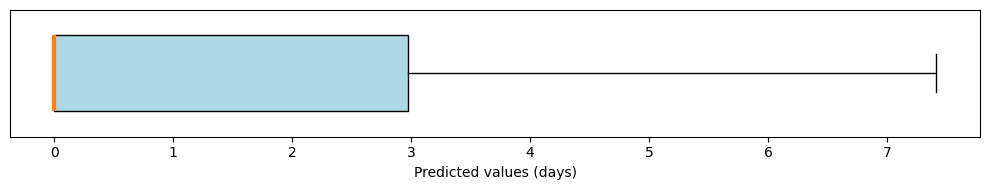

In [256]:
def plot_prediction_distributon(df: pd.DataFrame, title="Distribution of Predicted Values", xlabel="Pedicted values (hours)"):
    """
    Plots the distribution of absolute prediction errors in days.
    """
    df_temp = df.copy()
    df_temp['y_true_days'] = df_temp['y_true'].astype(float)/3600/24

    fig, ax = plt.subplots(figsize=(10, 2))

    ax.boxplot(df_temp['y_true_days'], 
               vert=False,
               widths=0.6,
               showfliers=False,
               patch_artist=True,
               boxprops=dict(facecolor='lightblue'),
               medianprops=dict(linewidth=3))
    
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('')
    ax.set_yticks([])
    plt.tight_layout()
    plt.show()

plot_prediction_distributon(df, title="", xlabel="Predicted values (days)")

In [199]:
def plot_event_count_by_hour_of_week(df: pd.DataFrame, by="time:timestamp", use_heat_map=True, title = "Event Volume by Hour of Week", xlabel="Hour of Week"):
    """
    Plots the total number of events aggregated by the hour of the week.
    Provides an option to color-code bars based on the event volume.
    """
    # ---------------------------------------------------------
    # 1. Data Preparation
    # ---------------------------------------------------------
    plot_df = df.copy()
    plot_df[by] = pd.to_datetime(plot_df[by], utc=True)
    
    # Calculate continuous hour of week [0, 167]
    plot_df['bucket_idx'] = (plot_df[by].dt.dayofweek * 24) + plot_df[by].dt.hour
    
    # Aggregate Event Count per hour
    agg_metrics = plot_df.groupby('bucket_idx').size().rename('event_count').reindex(range(168), fill_value=0)

    # ---------------------------------------------------------
    # 2. Visualization Setup
    # ---------------------------------------------------------
    fig, ax = plt.subplots(figsize=(10, 3))
    
    counts = agg_metrics.values
    
    # Configure bar colors depending on the selected visualization mode
    if use_heat_map:
        norm = colors.Normalize(vmin=counts.min(), vmax=counts.max())
        cmap = cm.get_cmap('plasma') 
        bar_colors = cmap(norm(counts))
    else:
        bar_colors = 'steelblue'

    # ---------------------------------------------------------
    # 3. Bar Plotting
    # ---------------------------------------------------------
    bars = ax.bar(
        agg_metrics.index,
        counts,
        color=bar_colors,
        width=0.85,
        align='center'
    )

    # ---------------------------------------------------------
    # 4. Formatting
    # ---------------------------------------------------------
    tick_indices = np.arange(0, 168, 6)
    day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
    
    def format_tick_label(idx):
        day_idx = idx // 24
        hour = idx % 24
        return f"{day_labels[day_idx]} {hour:02d}:00"

    tick_labels = [format_tick_label(i) for i in tick_indices]
    
    ax.set_xticks(tick_indices)
    ax.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=9)
    ax.set_xlim(-1, 168)
    
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Number of Events")
    ax.set_title(title)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    
    # Render colorbar exclusively for heat map visualization
    if use_heat_map:
        sm = cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax, pad=0.01)
        cbar.set_label('Number of Events (Volume)', rotation=270, labelpad=15)
    
    plt.tight_layout()
    plt.show()

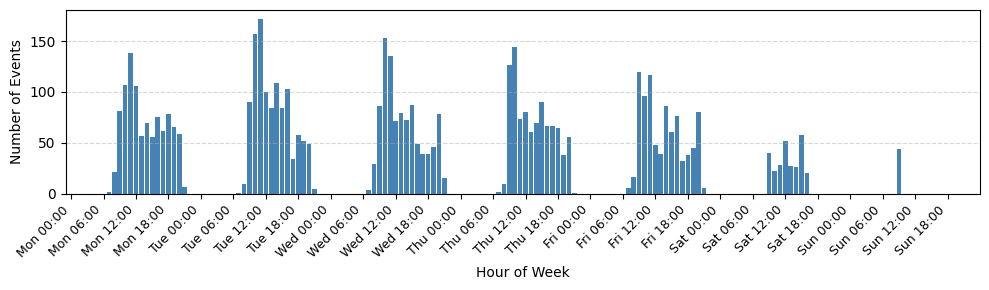

In [205]:
plot_event_count_by_hour_of_week(df, by="y_true_absolute", use_heat_map=False, title="", xlabel="Hour of Week")

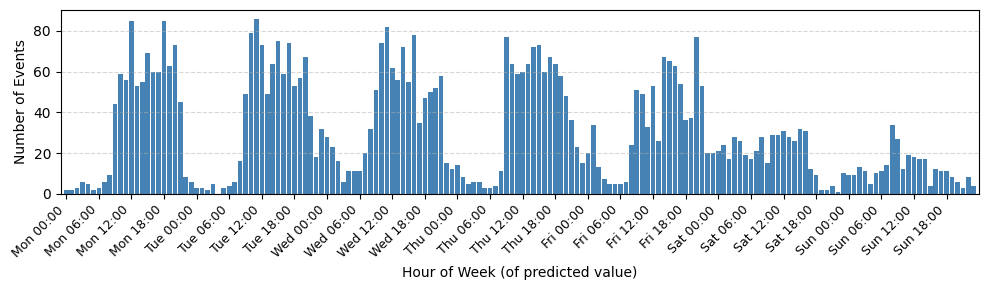

In [200]:
plot_event_count_by_hour_of_week(df, by="y_pred_absolute", use_heat_map=False, title="", xlabel="Hour of Week (of predicted value)")

## Multiple experiments

### Synthetic event logs

In [ ]:
experiments = ["syn_E10_sp00_we00_ct_agnostic",
               "syn_E10_sp00_we00_ct_aware",
               "syn_E10_sp00_we00_wt_agnostic",
               "syn_E10_sp00_we00_wt_aware",

               "syn_E10_sp05_we02_ct_agnostic",
               "syn_E10_sp05_we02_ct_aware",
               "syn_E10_sp05_we02_wt_agnostic",
               "syn_E10_sp05_we02_wt_aware",
               
               "syn_E10_sp10_we02_ct_agnostic",
               "syn_E10_sp10_we02_ct_aware",
               "syn_E10_sp10_we02_wt_agnostic",
               "syn_E10_sp10_we02_wt_aware",
               
               "syn_E10_sp30_we02_ct_agnostic",
               "syn_E10_sp30_we02_ct_aware",
               "syn_E10_sp30_we02_wt_agnostic",
               "syn_E10_sp30_we02_wt_aware",
               
               "syn_E10_sp90_we02_ct_agnostic",
               "syn_E10_sp90_we02_ct_aware",
               "syn_E10_sp90_we02_wt_agnostic",
               "syn_E10_sp90_we02_wt_aware"]

results = {}
for exp_name in experiments:
    exp = Experiment(Path(f"experiment/experiment_configs/experiment_{exp_name}.yaml"))
    res = exp.run()
    results[exp_name] = res


[Experiment]	    (1) Loaded log with 30000 events.
[Experiment]	    (2) Split log into 24000 train, 0 val, 6000 test cases.
[Experiment]	    (3) Identified 5 worktime intervals.
[Experiment]	    (4) Transformed log to worktime with column 'worktime:timestamp'.
[Experiment]	    (5) Generated prefixes: 129600 train, 0 val, 32400 test events.
[Experiment]	    (6) Engineered features: 11 features for 129600 train, 0 val, 32400 test events.
[Experiment]	    (7) Prepared target 'time_until_next_event': 129600 train, 0 val, 32400 test labels.
[Experiment]	    (8) Transformed data for model input into shape (21600, 10, 11) train, (0, 0, 11) val, (5400, 10, 11) test.
Epoch 1/100
675/675 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.1673 - mae: 0.1673
Epoch 2/100
675/675 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.1471 - mae: 0.1471
Epoch 3/100
675/675 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.1416 - mae: 0.1416
Epoch 4/100
675/675 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.1385 - mae: 0.1385
Epoch

E0000 00:00:1772534821.434861 1752305 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[Experiment]	    (10) Evaluated model.
[Experiment]	    (11) Saved experiment results to: artifacts/experiments/syn_E10_sp00_we00/syn_E10_sp00_we00_clocktime_minmax_tsl_20260303T104701Z.json
[Experiment]	    Experiment completed in 258.50 seconds.
[Experiment]	    (1) Loaded log with 30000 events.
[Experiment]	    (2) Split log into 24000 train, 0 val, 6000 test cases.
[Experiment]	    (3) Identified 5 worktime intervals.
[Experiment]	    (4) Transformed log to worktime with column 'worktime:timestamp'.
[Experiment]	    (5) Generated prefixes: 129600 train, 0 val, 32400 test events.
[Experiment]	    (6) Engineered features: 13 features for 129600 train, 0 val, 32400 test events.
[Experiment]	    (7) Prepared target 'time_until_next_event': 129600 train, 0 val, 32400 test labels.
[Experiment]	    (8) Transformed data for model input into shape (21600, 10, 13) train, (0, 0, 13) val, (5400, 10, 13) test.
Epoch 1/100
675/675 ━━━━━━━━━━━━━━━━━━━━ 3s 

E0000 00:00:1772535074.675083 1752305 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[Experiment]	    (10) Evaluated model.
[Experiment]	    (11) Saved experiment results to: artifacts/experiments/syn_E10_sp00_we00/syn_E10_sp00_we00_minmax_tax_20260303T105115Z.json
[Experiment]	    Experiment completed in 253.34 seconds.
[Experiment]	    (1) Loaded log with 30000 events.
[Experiment]	    (2) Split log into 24000 train, 0 val, 6000 test cases.
[Experiment]	    (3) Identified 5 worktime intervals.
[Experiment]	    (4) Transformed log to worktime with column 'worktime:timestamp'.
[Experiment]	    (5) Generated prefixes: 129600 train, 0 val, 32400 test events.
[Experiment]	    (6) Engineered features: 11 features for 129600 train, 0 val, 32400 test events.
[Experiment]	    (7) Prepared target 'time_until_next_event': 129600 train, 0 val, 32400 test labels.
[Experiment]	    (8) Transformed data for model input into shape (21600, 10, 11) train, (0, 0, 11) val, (5400, 10, 11) test.
Epoch 1/100
675/675 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step -

...

169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[Experiment]	    (10) Evaluated model.
[Experiment]	    (11) Saved experiment results to: artifacts/experiments/syn_E10_sp90_we02/syn_E10_sp90_we02_minmax_tax_20260303T120459Z.json
[Experiment]	    Experiment completed in 259.43 seconds.
[Experiment]	    (1) Loaded log with 30000 events.
[Experiment]	    (2) Split log into 24000 train, 0 val, 6000 test cases.
[Experiment]	    (3) Identified 5 worktime intervals.
[Experiment]	    (4) Transformed log to worktime with column 'worktime:timestamp'.
[Experiment]	    (5) Generated prefixes: 129600 train, 0 val, 32400 test events.
[Experiment]	    (6) Engineered features: 11 features for 129600 train, 0 val, 32400 test events.
[Experiment]	    (7) Prepared target 'time_until_next_event': 129600 train, 0 val, 32400 test labels.
[Experiment]	    (8) Transformed data for model input into shape (21600, 10, 11) train, (0, 0, 11) val, (5400, 10, 11) test.
Epoch 1/100
675/675 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step -

E0000 00:00:1772539762.823194 1752305 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[Experiment]	    (10) Evaluated model.
[Experiment]	    (11) Saved experiment results to: artifacts/experiments/syn_E10_sp90_we02/syn_E10_sp90_we02_worktime_minmax_tsl_20260303T120924Z.json
[Experiment]	    Experiment completed in 264.83 seconds.
[Experiment]	    (1) Loaded log with 30000 events.
[Experiment]	    (2) Split log into 24000 train, 0 val, 6000 test cases.
[Experiment]	    (3) Identified 5 worktime intervals.
[Experiment]	    (4) Transformed log to worktime with column 'worktime:timestamp'.
[Experiment]	    (5) Generated prefixes: 129600 train, 0 val, 32400 test events.
[Experiment]	    (6) Engineered features: 13 features for 129600 train, 0 val, 32400 test events.
[Experiment]	    (7) Prepared target 'time_until_next_event': 129600 train, 0 val, 32400 test labels.
[Experiment]	    (8) Transformed data for model input into shape (21600, 10, 13) train, (0, 0, 13) val, (5400, 10, 13) test.
Epoch 1/100
675/675 ━━━━━━━━━━━━━━━━━━━━ 4s 4

E0000 00:00:1772540090.140369 1752305 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[Experiment]	    (10) Evaluated model.
[Experiment]	    (11) Saved experiment results to: artifacts/experiments/syn_E10_sp90_we02/syn_E10_sp90_we02_worktime_minmax_tax_20260303T121452Z.json
[Experiment]	    Experiment completed in 327.31 seconds.


In [66]:
def process_result_entry(res):
    """
    Berechnet Vorhersagefehler und absolute Zeitstempel basierend auf 
    dem letzten Event jedes Falls.
    """
    # Datenextraktion und Sortierung
    df = res.pref_te.sort_values(by=["time:timestamp"])
    
    # Aggregation auf den letzten Status pro Fall
    df = df.groupby('case:concept:name').last()
    
    # Integration der Vorhersagewerte und Fehlerberechnung
    df["y_pred"] = res.y_pred.values
    df["y_true"] = res.y_true.values
    df["abs_error"] = np.abs(df["y_pred"] - df["y_true"])
    
    # Umrechnung in absolute Zeitstempel
    df["y_pred_absolute"] = df["time:timestamp"] + pd.to_timedelta(df["y_pred"], unit='s')
    df["y_true_absolute"] = df["time:timestamp"] + pd.to_timedelta(df["y_true"], unit='s')
    
    return df

# Erstellung des neuen Dictionarys mit verarbeiteten DataFrames
result_dfs = {key: process_result_entry(res) for key, res in results.items()}

In [ ]:
# Create a folder for the results
output_dir = 'artifacts/result_data_csv'
os.makedirs(output_dir, exist_ok=True)

# Save each DataFrame using its dictionary key as the filename
for key, df in result_dfs.items():
    # Replace any characters that might be invalid for filenames
    safe_filename = key.replace('/', '_').replace('\\', '_')
    df.to_csv(f"{output_dir}/{safe_filename}.csv", index=False)

# Reconstruct the dictionary later
#import glob
#loaded_dfs = {}
#for file_path in glob.glob(f"{output_dir}/*.csv"):
#    key = os.path.basename(file_path).replace('.csv', '')
#    loaded_dfs[key] = pd.read_csv(file_path)

In [101]:
result_dfs["syn_E10_sp00_we00_ct_agnostic"].head()

,concept:name,time:timestamp,worktime:timestamp,prefix_length,y_pred,y_true,abs_error,y_pred_absolute,y_true_absolute
case:concept:name,,,,,,,,,
Case_0001::prefix_0002,Activity_1,2026-03-11 08:55:00+00:00,5498 days 06:55:00,2,4232.783691,4020.000244,212.783447,2026-03-11 10:05:32.783691406+00:00,2026-03-11 10:02:00.000244141+00:00
Case_0001::prefix_0003,Activity_2,2026-03-11 10:02:00+00:00,5498 days 08:02:00,3,4218.589355,4680.000000,461.410645,2026-03-11 11:12:18.589355469+00:00,2026-03-11 11:20:00+00:00
Case_0001::prefix_0004,Activity_3,2026-03-11 11:20:00+00:00,5498 days 09:20:00,4,3923.343506,3240.000000,683.343506,2026-03-11 12:25:23.343505859+00:00,2026-03-11 12:14:00+00:00
Case_0001::prefix_0005,Activity_4,2026-03-11 12:14:00+00:00,5498 days 10:14:00,5,4358.558105,2040.000000,2318.558105,2026-03-11 13:26:38.558105469+00:00,2026-03-11 12:48:00+00:00
Case_0001::prefix_0006,Activity_5,2026-03-11 12:48:00+00:00,5498 days 10:48:00,6,4977.922852,4380.000000,597.922852,2026-03-11 14:10:57.922851562+00:00,2026-03-11 14:01:00+00:00


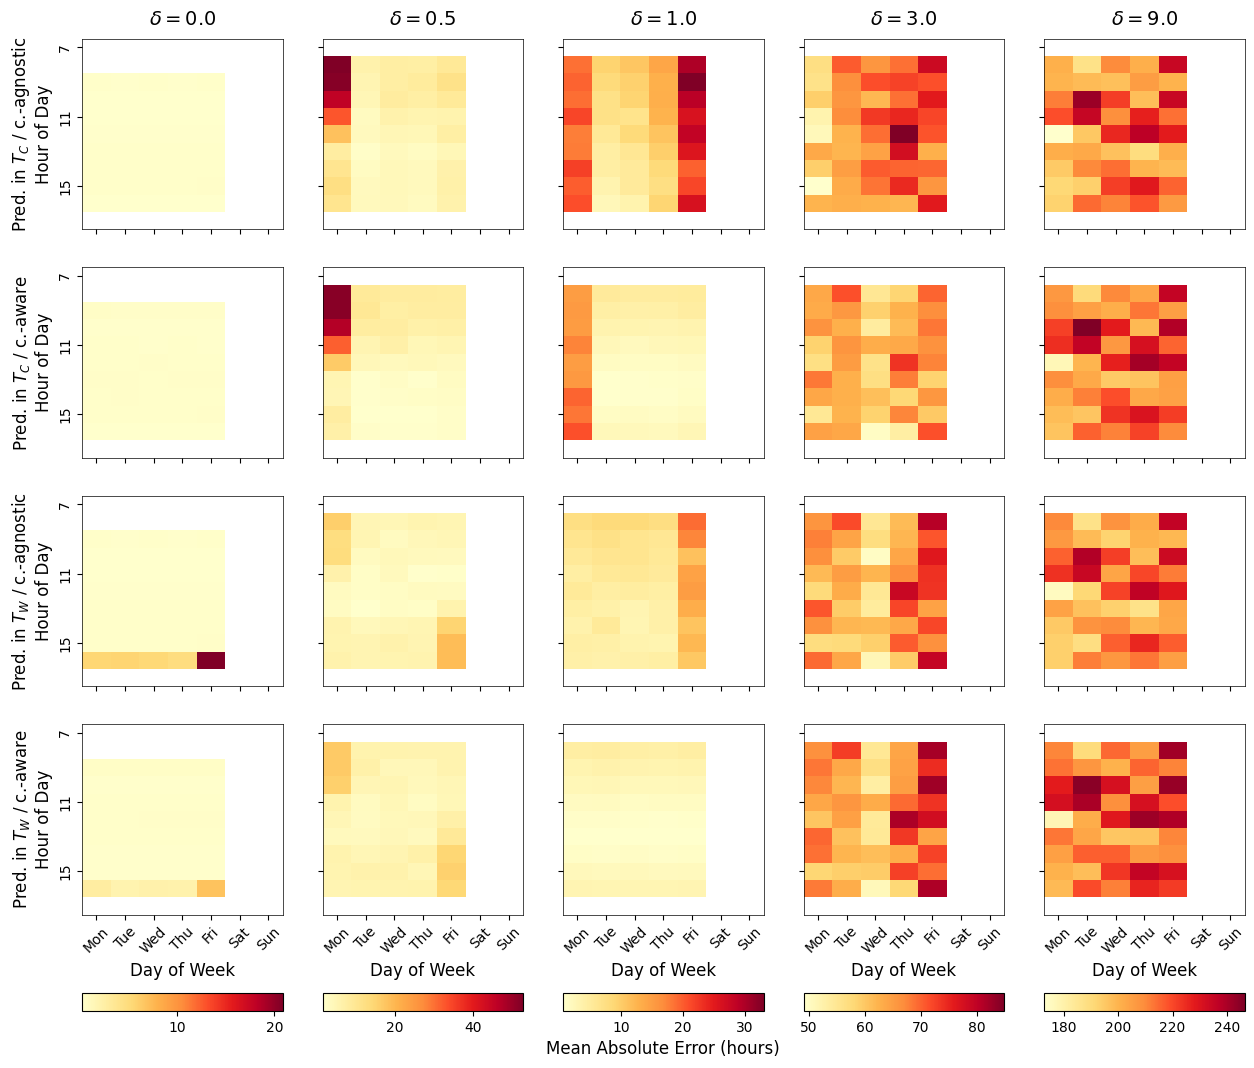

In [104]:
# --- 1. Mapping Config ---
density_map = {
    '0.0': 'sp00',
    '0.5': 'sp05',
    '1.0': 'sp10',
    '3.0': 'sp30',
    '9.0': 'sp90'
}

configs_map = {
    'CT (tsl)':        ('ct_agnostic', r'Pred. in $T_C$ / c.-agnostic'),
    'CT (tax)':        ('ct_aware',    r'Pred. in $T_C$ / c.-aware'),
    'WT in CT (tsl)':  ('wt_agnostic', r'Pred. in $T_W$ / c.-agnostic'),
    'WT in CT (tax)':  ('wt_aware',    r'Pred. in $T_W$ / c.-aware'),
}

# --- 2. 2D Data Processing Function ---
def get_2d_error_matrix(df, min_entries=10):
    """Calculates MAE grouped by Day of Week and Hour of Day, masking low-frequency bins."""
    df_temp = df.copy()
    
    df_temp['y_true_absolute'] = pd.to_datetime(df_temp['y_true_absolute'], utc=True, errors='coerce')
    df_temp = df_temp.dropna(subset=['y_true_absolute'])
    
    if df_temp.empty:
        return pd.DataFrame(np.nan, index=range(7,18), columns=range(7))

    df_temp['day_of_week'] = df_temp['y_true_absolute'].dt.dayofweek
    df_temp['hour_of_day'] = df_temp['y_true_absolute'].dt.hour
    
    df_temp['abs_error'] = df_temp['abs_error'] / 3600

    # Calculate means and observation counts
    pivot_mean = df_temp.pivot_table(
        index='hour_of_day', 
        columns='day_of_week', 
        values='abs_error', 
        aggfunc='mean'
    )
    
    pivot_count = df_temp.pivot_table(
        index='hour_of_day', 
        columns='day_of_week', 
        values='abs_error', 
        aggfunc='count'
    )
    
    # Mask cells lacking statistical robustness
    pivot_mean[pivot_count < min_entries] = np.nan
    
    return pivot_mean.reindex(index=range(7,18), columns=range(7))

# --- 3. Compute Column-wise Minimum and Maximums ---
col_limits = {}

for col_idx, (density_val, density_code) in enumerate(density_map.items()):
    c_min = float("inf")
    c_max = float("-inf")
    we_code = 'we00' if density_code == 'sp00' else 'we02'

    for _, (cfg_code, _) in configs_map.items():
        dict_key = f"syn_E10_{density_code}_{we_code}_{cfg_code}"
        df = result_dfs.get(dict_key)
        
        if df is not None and not df.empty:
            df_temp = df.copy()
            df_temp['y_true_absolute'] = pd.to_datetime(df_temp['y_true_absolute'], utc=True, errors='coerce')
            df_temp = df_temp.dropna(subset=['y_true_absolute'])
            
            if not df_temp.empty:
                df_temp['day_of_week'] = df_temp['y_true_absolute'].dt.dayofweek
                df_temp['hour_of_day'] = df_temp['y_true_absolute'].dt.hour
                
                # Group data to extract means and frequencies
                grouped = df_temp.groupby(['day_of_week', 'hour_of_day'])['abs_error']
                mean_errs = grouped.mean() / 3600
                counts = grouped.count()
                
                # Apply frequency threshold before calculating limits
                valid_means = mean_errs[counts >= 10]
                
                if not valid_means.empty:
                    c_min = min(c_min, valid_means.min())
                    c_max = max(c_max, valid_means.max())
    
    if c_max == float("-inf"):
        c_min, c_max = 0, 1
        
    col_limits[col_idx] = (c_min, c_max)


# --- 4. Figure Layout Setup ---
fig, axes = plt.subplots(4, 5, figsize=(15, 12), sharex=True, sharey=True)
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

if axes.ndim == 1: axes = np.expand_dims(axes, 0)

# --- 5. Plotting Execution ---
for row_idx, (config_name, (cfg_code, cfg_label)) in enumerate(configs_map.items()):
    for col_idx, (density_val, density_code) in enumerate(density_map.items()):
        
        ax = axes[row_idx, col_idx]
        
        we_code = 'we00' if density_code == 'sp00' else 'we02'
        dict_key = f"syn_E10_{density_code}_{we_code}_{cfg_code}"
        
        target_df = result_dfs.get(dict_key)
        
        c_min, c_max = col_limits[col_idx]
        
        if target_df is not None and not target_df.empty:
            heatmap_data = get_2d_error_matrix(target_df, min_entries=10)
            
            sns.heatmap(heatmap_data, ax=ax, cmap="YlOrRd", 
                        vmin=c_min, vmax=c_max,
                        cbar=False, 
                        yticklabels=4, 
                        xticklabels=day_labels)
        else:
            sns.heatmap(pd.DataFrame(np.nan, index=range(7,18), columns=range(7)), 
                        ax=ax, cmap="YlOrRd", vmin=0, vmax=1, cbar=False)

        # Apply formatting
        for _, spine in ax.spines.items():
            spine.set_visible(True)
            spine.set_linewidth(0.5)
            spine.set_color('black')

        if row_idx == 0:
            ax.set_title(rf"$\delta = {density_val}$", fontsize=14, pad=10)
        
        if col_idx == 0:
            ax.set_ylabel(f"{cfg_label}\nHour of Day", fontsize=12)
        else:
            ax.set_ylabel("")
            
        if row_idx == 3:
            ax.set_xlabel("Day of Week", fontsize=12)
            ax.tick_params(axis='x', rotation=45)
        else:
            ax.set_xlabel("")

plt.subplots_adjust(bottom=0.15)

# --- 6. Append Legends Below Columns ---
for col_idx in range(5):
    bottom_ax = axes[3, col_idx]
    
    pos = bottom_ax.get_position()
    
    cbar_ax = fig.add_axes([pos.x0, pos.y0 - 0.08, pos.width, 0.015]) 
    
    c_min, c_max = col_limits[col_idx]
    
    sm = plt.cm.ScalarMappable(cmap="YlOrRd", norm=plt.Normalize(vmin=c_min, vmax=c_max))
    sm.set_array([])
    
    cb = ColorbarBase(cbar_ax, cmap="YlOrRd", norm=plt.Normalize(vmin=c_min, vmax=c_max), orientation='horizontal')
    
    if col_idx == 2:
        cb.set_label('Mean Absolute Error (hours)', fontsize=12)
        
plt.show()

### Real-world event logs

In [ ]:
experiments = ["BPI_2012_O_ct_agnostic",
               "BPI_2012_O_ct_aware",
               "BPI_2012_O_wt_agnostic",
               "BPI_2012_O_wt_aware",
               "BPI_2012_A_ct_agnostic",
               "BPI_2012_A_ct_aware",
               "BPI_2012_A_wt_agnostic",
               "BPI_2012_A_wt_aware",
               "BPI_2012_W_ct_agnostic",
               "BPI_2012_W_ct_aware",
               "BPI_2012_W_wt_agnostic",
               "BPI_2012_W_wt_aware",
               "helpdesk_ct_agnostic",
               "helpdesk_ct_aware",
               "helpdesk_wt_agnostic",
               "helpdesk_wt_aware",
               "prepaid_travel_cost_ct_agnostic",
               "prepaid_travel_cost_ct_aware",
               "prepaid_travel_cost_wt_agnostic",
               "prepaid_travel_cost_wt_aware",
               "request_for_payment_ct_agnostic",
               "request_for_payment_ct_aware",
               "request_for_payment_wt_agnostic",
               "request_for_payment_wt_aware"]

results_rw = {}
for exp_name in experiments:
    exp = Experiment(Path(f"experiment/experiment_configs/experiment_{exp_name}.yaml"))
    res = exp.run()
    results_rw[exp_name] = res


[Experiment]	    (1) Loaded log with 60849 events.
[Experiment]	    (2) Split log into 47823 train, 0 val, 13026 test cases.
[Experiment]	    (3) Identified 8 worktime intervals.
[Experiment]	    (4) Transformed log to worktime with column 'worktime:timestamp'.
[Experiment]	    (5) Generated prefixes: 141244 train, 0 val, 40751 test events.
[Experiment]	    (6) Engineered features: 11 features for 141244 train, 0 val, 40751 test events.
[Experiment]	    (7) Prepared target 'time_until_next_event': 141244 train, 0 val, 40751 test labels.
[Experiment]	    (8) Transformed data for model input into shape (37353, 8, 11) train, (0, 0, 11) val, (10409, 8, 11) test.
Epoch 1/100


E0000 00:00:1772551703.514109 1752305 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


1168/1168 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0180 - mae: 0.0180
Epoch 2/100
1168/1168 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0158 - mae: 0.0158
Epoch 3/100
1168/1168 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0150 - mae: 0.0150
Epoch 4/100
1168/1168 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0146 - mae: 0.0146
Epoch 5/100
1168/1168 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0145 - mae: 0.0145
Epoch 6/100
1168/1168 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0144 - mae: 0.0144
Epoch 7/100
1168/1168 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0142 - mae: 0.0142
Epoch 8/100
1168/1168 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0141 - mae: 0.0141
Epoch 9/100
1168/1168 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0141 - mae: 0.0141
Epoch 10/100
1168/1168 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0140 - mae: 0.0140
Epoch 11/100
1168/1168 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0140 - mae: 0.0140
Epoch 12/100
1168/1168 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0139 - mae: 0.0139
E

E0000 00:00:1772552163.349484 1752305 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[Experiment]	    (10) Evaluated model.
[Experiment]	    (11) Saved experiment results to: artifacts/experiments/BPI_2012_A/BPI_2012_A_clocktime_minmax_tsl_20260303T153604Z.json
[Experiment]	    Experiment completed in 493.47 seconds.
[Experiment]	    (1) Loaded log with 60849 events.
[Experiment]	    (2) Split log into 47823 train, 0 val, 13026 test cases.
[Experiment]	    (3) Identified 8 worktime intervals.
[Experiment]	    (4) Transformed log to worktime with column 'worktime:timestamp'.
[Experiment]	    (5) Generated prefixes: 141244 train, 0 val, 40751 test events.
[Experiment]	    (6) Engineered features: 13 features for 141244 train, 0 val, 40751 test events.
[Experiment]	    (7) Prepared target 'time_until_next_event': 141244 train, 0 val, 40751 test labels.
[Experiment]	    (8) Transformed data for model input into shape (37353, 8, 13) train, (0, 0, 13) val, (10409, 8, 13) test.
Epoch 1/100


...

195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[Experiment]	    (10) Evaluated model.
[Experiment]	    (11) Saved experiment results to: artifacts/experiments/request_for_payment/request_for_payment_worktime_minmax_tsl_20260303T200208Z.json
[Experiment]	    Experiment completed in 321.76 seconds.
[Experiment]	    (1) Loaded log with 36796 events.
[Experiment]	    (2) Split log into 29201 train, 0 val, 7595 test cases.
[Experiment]	    (3) Identified 6 worktime intervals.
[Experiment]	    (4) Transformed log to worktime with column 'worktime:timestamp'.
[Experiment]	    (5) Generated prefixes: 92521 train, 0 val, 24716 test events.
[Experiment]	    (6) Engineered features: 21 features for 92521 train, 0 val, 24716 test events.
[Experiment]	    (7) Prepared target 'time_until_next_event': 92521 train, 0 val, 24716 test labels.
[Experiment]	    (8) Transformed data for model input into shape (23692, 16, 21) train, (0, 0, 21) val, (6218, 20, 21) test.
Epoch 1/100


E0000 00:00:1772568198.447017 1752305 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


741/741 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0098 - mae: 0.0098
Epoch 2/100
741/741 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0087 - mae: 0.0087
Epoch 3/100
741/741 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0085 - mae: 0.0085
Epoch 4/100
741/741 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0083 - mae: 0.0083
Epoch 5/100
741/741 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0083 - mae: 0.0083
Epoch 6/100
741/741 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0082 - mae: 0.0082
Epoch 7/100
741/741 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0082 - mae: 0.0082
Epoch 8/100
741/741 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0082 - mae: 0.0082
Epoch 9/100
741/741 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0081 - mae: 0.0081
Epoch 10/100
741/741 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0081 - mae: 0.0081
Epoch 11/100
741/741 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0081 - mae: 0.0081
Epoch 12/100
741/741 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0081 - mae: 0.0081
Epoch 13/100
741/741 ━━━━

E0000 00:00:1772568498.415475 1752305 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[Experiment]	    (10) Evaluated model.
[Experiment]	    (11) Saved experiment results to: artifacts/experiments/request_for_payment/request_for_payment_worktime_minmax_tax_20260303T200820Z.json
[Experiment]	    Experiment completed in 372.33 seconds.


In [175]:
result_dfs_rw = {key: process_result_entry(res) for key, res in results_rw.items()}

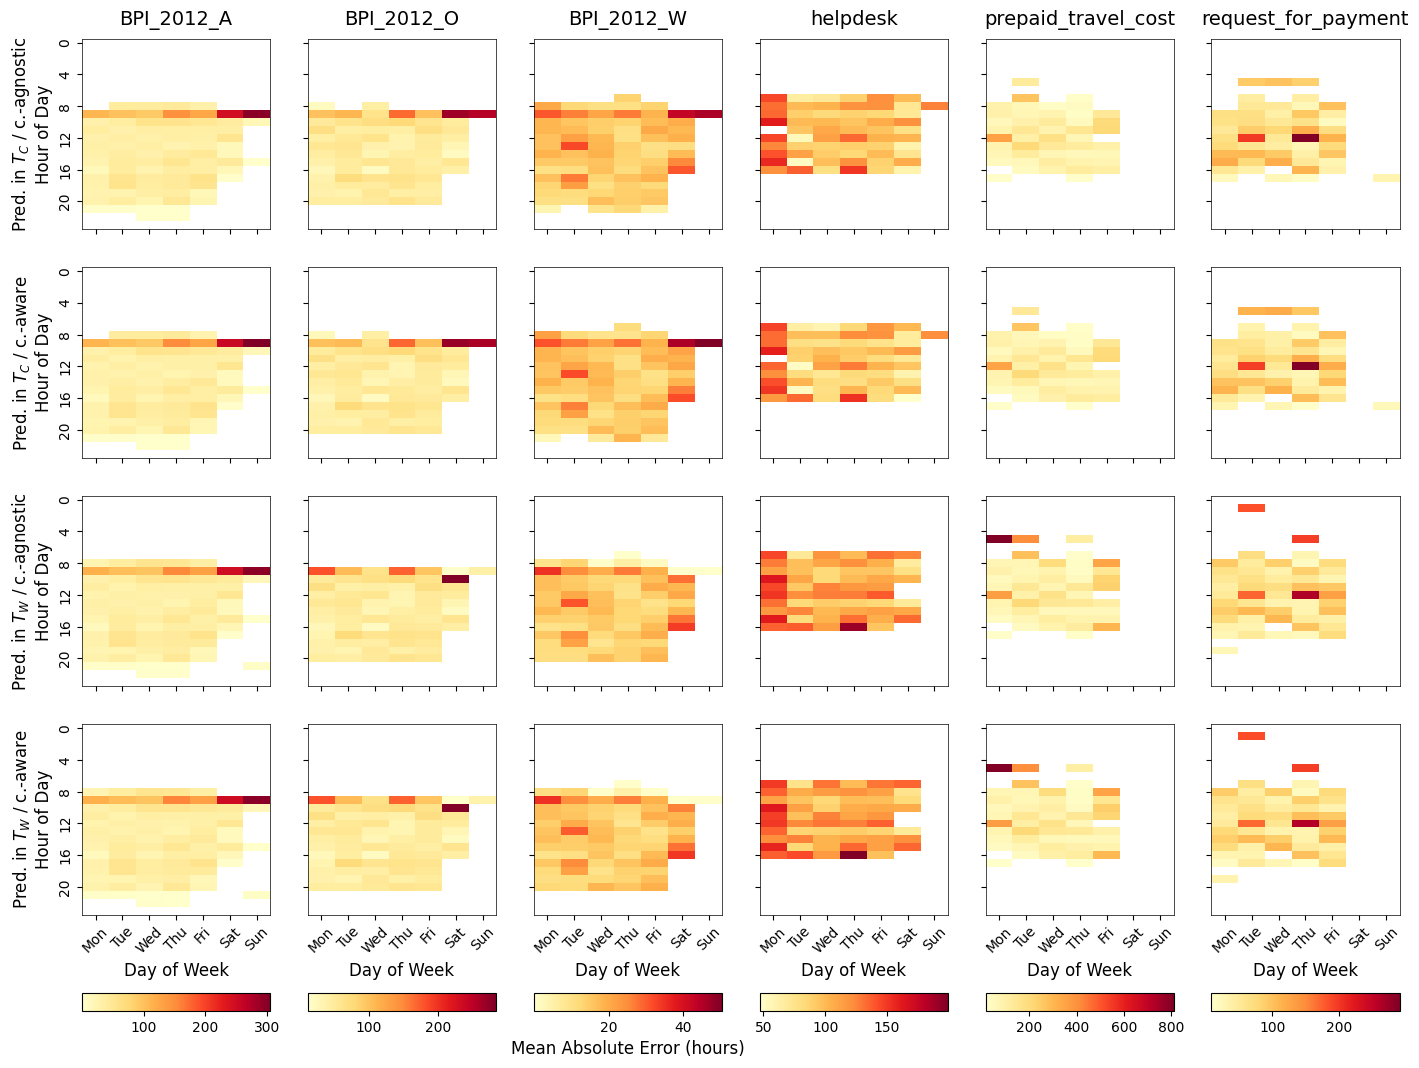

In [180]:
# --- 1. Mapping Config ---
datasets_map = [
    'BPI_2012_A', 'BPI_2012_O', 'BPI_2012_W', 
    'helpdesk', 'prepaid_travel_cost', 'request_for_payment'
]

configs_map = {
    'CT (tsl)':        ('ct_agnostic', r'Pred. in $T_C$ / c.-agnostic'),
    'CT (tax)':        ('ct_aware',    r'Pred. in $T_C$ / c.-aware'),
    'WT in CT (tsl)':  ('wt_agnostic', r'Pred. in $T_W$ / c.-agnostic'),
    'WT in CT (tax)':  ('wt_aware',    r'Pred. in $T_W$ / c.-aware'),
}

# --- 2. 2D Data Processing Function ---
def get_2d_error_matrix(df, min_entries=10):
    """Calculates MAE grouped by Day of Week and Hour of Day, masking low-frequency bins."""
    df_temp = df.copy()
    
    df_temp['y_true_absolute'] = pd.to_datetime(df_temp['y_true_absolute'], utc=True, errors='coerce')
    df_temp = df_temp.dropna(subset=['y_true_absolute'])
    
    if df_temp.empty:
        return pd.DataFrame(np.nan, index=range(0,24), columns=range(7))

    df_temp['day_of_week'] = df_temp['y_true_absolute'].dt.dayofweek
    df_temp['hour_of_day'] = df_temp['y_true_absolute'].dt.hour
    
    df_temp['abs_error'] = df_temp['abs_error'] / 3600

    # Calculate means and observation counts
    pivot_mean = df_temp.pivot_table(
        index='hour_of_day', 
        columns='day_of_week', 
        values='abs_error', 
        aggfunc='mean'
    )
    
    pivot_count = df_temp.pivot_table(
        index='hour_of_day', 
        columns='day_of_week', 
        values='abs_error', 
        aggfunc='count'
    )
    
    # Mask cells lacking statistical robustness
    pivot_mean[pivot_count < min_entries] = np.nan
    
    return pivot_mean.reindex(index=range(0,24), columns=range(7))

# --- 3. Compute Column-wise Minimum and Maximums ---
col_limits = {}

for col_idx, dataset_name in enumerate(datasets_map):
    c_min = float("inf")
    c_max = float("-inf")
    #we_code = 'we00' if density_code == 'sp00' else 'we02'

    for _, (cfg_code, _) in configs_map.items():
        dict_key = f"{dataset_name}_{cfg_code}"
        df = result_dfs_rw.get(dict_key)
        
        if df is not None and not df.empty:
            df_temp = df.copy()
            df_temp['y_true_absolute'] = pd.to_datetime(df_temp['y_true_absolute'], utc=True, errors='coerce')
            df_temp = df_temp.dropna(subset=['y_true_absolute'])
            
            if not df_temp.empty:
                df_temp['day_of_week'] = df_temp['y_true_absolute'].dt.dayofweek
                df_temp['hour_of_day'] = df_temp['y_true_absolute'].dt.hour
                
                # Group data to extract means and frequencies
                grouped = df_temp.groupby(['day_of_week', 'hour_of_day'])['abs_error']
                mean_errs = grouped.mean() / 3600
                counts = grouped.count()
                
                # Apply frequency threshold before calculating limits
                valid_means = mean_errs[counts >= 20]
                
                if not valid_means.empty:
                    c_min = min(c_min, valid_means.min())
                    c_max = max(c_max, valid_means.max())
    
    if c_max == float("-inf"):
        c_min, c_max = 0, 1
        
    col_limits[col_idx] = (c_min, c_max)


# --- 4. Figure Layout Setup ---
fig, axes = plt.subplots(4, 6, figsize=(17, 12), sharex=True, sharey=True)
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

if axes.ndim == 1: axes = np.expand_dims(axes, 0)

# --- 5. Plotting Execution ---
for row_idx, (config_name, (cfg_code, cfg_label)) in enumerate(configs_map.items()):
    for col_idx, dataset_name in enumerate(datasets_map):
        
        ax = axes[row_idx, col_idx]
        
        dict_key = f"{dataset_name}_{cfg_code}"
        
        target_df = result_dfs_rw.get(dict_key)
        
        c_min, c_max = col_limits[col_idx]
        
        if target_df is not None and not target_df.empty:
            heatmap_data = get_2d_error_matrix(target_df, min_entries=20)
            
            sns.heatmap(heatmap_data, ax=ax, cmap="YlOrRd", 
                        vmin=c_min, vmax=c_max,
                        cbar=False, 
                        yticklabels=4, 
                        xticklabels=day_labels)
        else:
            sns.heatmap(pd.DataFrame(np.nan, index=range(0,24), columns=range(7)), 
                        ax=ax, cmap="YlOrRd", vmin=0, vmax=1, cbar=False)

        # Apply formatting
        for _, spine in ax.spines.items():
            spine.set_visible(True)
            spine.set_linewidth(0.5)
            spine.set_color('black')

        if row_idx == 0:
            ax.set_title(dataset_name, fontsize=14, pad=10)
        
        if col_idx == 0:
            ax.set_ylabel(f"{cfg_label}\nHour of Day", fontsize=12)
        else:
            ax.set_ylabel("")
            
        if row_idx == 3:
            ax.set_xlabel("Day of Week", fontsize=12)
            ax.tick_params(axis='x', rotation=45)
            
        else:
            ax.set_xlabel("")

plt.subplots_adjust(bottom=0.15)

# --- 6. Append Legends Below Columns ---
for col_idx in range(6):
    bottom_ax = axes[3, col_idx]
    
    pos = bottom_ax.get_position()
    
    cbar_ax = fig.add_axes([pos.x0, pos.y0 - 0.08, pos.width, 0.015]) 
    
    c_min, c_max = col_limits[col_idx]
    
    sm = plt.cm.ScalarMappable(cmap="YlOrRd", norm=plt.Normalize(vmin=c_min, vmax=c_max))
    sm.set_array([])
    
    cb = ColorbarBase(cbar_ax, cmap="YlOrRd", norm=plt.Normalize(vmin=c_min, vmax=c_max), orientation='horizontal')
    
    if col_idx == 2:
        cb.set_label('Mean Absolute Error (hours)', fontsize=12)
        
plt.show()